## Imports

In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
import pickle
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import matplotlib
from scipy.linalg import solve_discrete_lyapunov
matplotlib.use('Agg')
try:
    from numba import njit
    print("Numba available — JIT compilation enabled.")
except ImportError:
    print("Numba not available — running in pure Python mode.")
    def njit(fn=None, **kwargs):
        if fn is not None:
            return fn
        return lambda f: f

Numba available — JIT compilation enabled.


In [22]:
%matplotlib inline

## Data & preprocessing

In [23]:
freq      = "seasonal"
df        = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
block_cov = pd.read_csv(f'../data/block_cov_{freq}.csv')
block_cov = block_cov.set_index(['country', 'time_block'])

all_countries = df['country'].unique()
cont_map  = df.drop_duplicates('country').set_index('country')['continent'].to_dict()
cont_list = sorted(set(cont_map.values()))
cont_idx  = {c: i for i, c in enumerate(cont_list)}
n_cont    = len(cont_list)

all_blocks = sorted(df['time_block'].unique())
n_blocks   = len(all_blocks)
block_idx  = {b: i for i, b in enumerate(all_blocks)}

#sigma2 = 0.03

print(df.columns.tolist())
print(block_cov.columns.tolist())

['country', 'date', 'log_cases', 'continent', 'pc1', 'pc2', 'time_block']
['stringency_lag', 'vac_lag', 'log_vac_lag']


## Country-level train/holdout split

Hold out 20% of countries entirely from EM training.

In [24]:
np.random.seed(42)
n_holdout         = max(1, int(len(all_countries) * 0.2))
holdout_countries = set(np.random.choice(all_countries, size=n_holdout, replace=False))
train_countries   = [c for c in all_countries if c not in holdout_countries]

print(f"Total countries:   {len(all_countries)}")
print(f"Train countries:   {len(train_countries)}")
print(f"Holdout countries: {len(holdout_countries)}")
print(f"Holdout set: {sorted(holdout_countries)}")

# EM operates only on train countries
countries = np.array(train_countries)

Total countries:   121
Train countries:   97
Holdout countries: 24
Holdout set: ['Afghanistan', 'Austria', 'Belarus', 'Belgium', 'Burundi', 'Croatia', 'Dominica', 'Estonia', 'Finland', 'Germany', 'Ghana', 'Guatemala', 'Iran', 'Jordan', 'Kuwait', 'Laos', 'Luxembourg', 'Malta', 'Panama', 'Paraguay', 'South Korea', 'Sweden', 'Togo', 'Uruguay']


## Helper functions

In [25]:
def _build_cov_arrays():
    df_by_country = {}
    str_arr, vac_arr = {}, {}
    for c in all_countries:   # build for ALL countries including holdout
        df_c = df[df['country'] == c].sort_values('date').reset_index(drop=True)
        df_by_country[c] = df_c
        T = len(df_c)
        sv = np.zeros(T); vv = np.zeros(T)
        for i, row in df_c.iterrows():
            key = (c, row['time_block'])
            if key in block_cov.index:
                sv[i] = float(block_cov.loc[key, 'stringency_lag'])
                vv[i] = float(block_cov.loc[key, 'log_vac_lag'])
        str_arr[c] = sv
        vac_arr[c] = vv
    return df_by_country, str_arr, vac_arr

df_by_country, _str_arr, _vac_arr = _build_cov_arrays()


def compute_mu_t_c(c, beta, theta_c, delta=None):
    df_c = df_by_country[c]
    T    = len(df_c)
    U_c1 = float(df_c['pc1'].iloc[0])
    U_c2 = float(df_c['pc2'].iloc[0])
    sv   = _str_arr[c]; vv = _vac_arr[c]
    X = np.column_stack([np.ones(T), np.full(T, U_c1), np.full(T, U_c2), sv, vv])
    if delta is None:
        return X @ beta + theta_c
    else:
        blocks = df_c['time_block'].values
        D_mat  = np.array([delta.get(b, np.zeros(5)) for b in blocks])
        return np.sum(X * (beta + D_mat), axis=1) + theta_c


def get_block_covariates(country, time_block):
    key = (country, time_block)
    if key in block_cov.index:
        return (float(block_cov.loc[key, 'stringency_lag']),
                float(block_cov.loc[key, 'log_vac_lag']))
    return 0.0, 0.0

## Kalman filter & RTS smoother

In [26]:
@njit
def kalman_filter_scalar(Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, sigma2):
    T      = len(Y)
    mu_f   = np.zeros(T); Sigma_f = np.zeros(T)
    mu_p   = np.zeros(T); Sigma_p = np.zeros(T)
    log_ml = 0.0
    for t in range(T):
        if t == 0:
            mu_p[t]    = mu_s_1
            Sigma_p[t] = Sigma_s_1
        else:
            mu_p[t]    = mu_f[t-1] + mu_seq[t]
            Sigma_p[t] = Sigma_f[t-1] + sigma2
        innov      = Y[t] - log_pc - mu_p[t]
        H_t        = Sigma_p[t] + tau2
        K_t        = Sigma_p[t] / H_t
        mu_f[t]    = mu_p[t]  + K_t * innov
        Sigma_f[t] = (1.0 - K_t) * Sigma_p[t]
        log_ml    += -0.5 * (np.log(2.0 * np.pi * H_t) + innov**2 / H_t)
    return mu_f, Sigma_f, mu_p, Sigma_p, log_ml


@njit
def rts_smoother_scalar(mu_f, Sigma_f, mu_p, Sigma_p):
    T             = len(mu_f)
    mu_s          = mu_f.copy(); Sigma_s = Sigma_f.copy()
    Sigma_s_cross = np.zeros(T - 1)
    for t in range(T - 2, -1, -1):
        G_t              = Sigma_f[t] / Sigma_p[t + 1]
        mu_s[t]          = mu_f[t]  + G_t * (mu_s[t+1]  - mu_p[t+1])
        Sigma_s[t]       = Sigma_f[t] + G_t**2 * (Sigma_s[t+1] - Sigma_p[t+1])
        Sigma_s_cross[t] = G_t * Sigma_s[t+1]
    return mu_s, Sigma_s, Sigma_s_cross


def make_companion_matrix(rho_vec):
    p = len(rho_vec); d = p + 1
    A = np.zeros((d, d))
    A[0, 0] = 1.0; A[0, 1:] = rho_vec; A[1, 1:] = rho_vec
    for k in range(2, d):
        A[k, k-1] = 1.0
    return A


@njit
def kalman_filter_arp(Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, A, Q, sigma2):
    d  = A.shape[0]; T = len(Y)
    mu_f  = np.zeros((T, d)); Sig_f = np.zeros((T, d, d))
    mu_p  = np.zeros((T, d)); Sig_p = np.zeros((T, d, d))
    log_ml = 0.0
    for t in range(T):
        if t == 0:
            mu_p[t, 0] = mu_s_1
            # for i in range(d):
            #     Sig_p[t, i, i] = Sigma_s_1
            Sig_p[t] = Sigma_s_1
        else:
            for i in range(d):
                s = 0.0
                for j in range(d):
                    s += A[i, j] * mu_f[t-1, j]
                mu_p[t, i] = s
            mu_p[t, 0] += mu_seq[t]; mu_p[t, 1] += mu_seq[t]
            for i in range(d):
                for j in range(d):
                    s = 0.0
                    for k in range(d):
                        for l in range(d):
                            s += A[i, k] * Sig_f[t-1, k, l] * A[j, l]
                    Sig_p[t, i, j] = s + Q[i, j]
        innov = Y[t] - log_pc - mu_p[t, 0]
        H_t   = Sig_p[t, 0, 0] + tau2
        if H_t < 1e-8: H_t = 1e-8
        for i in range(d):
            K_i = Sig_p[t, i, 0] / H_t
            mu_f[t, i] = mu_p[t, i] + K_i * innov
        for i in range(d):
            K_i = Sig_p[t, i, 0] / H_t
            for j in range(d):
                Sig_f[t, i, j] = Sig_p[t, i, j] - K_i * Sig_p[t, 0, j]
        log_ml += -0.5 * (np.log(2.0 * np.pi * H_t) + innov**2 / H_t)
    return mu_f, Sig_f, mu_p, Sig_p, log_ml


@njit
def rts_smoother_arp(mu_f, Sig_f, mu_p, Sig_p, A):
    T  = mu_f.shape[0]; d = mu_f.shape[1]
    mu_s        = mu_f.copy(); Sig_s = Sig_f.copy()
    Sig_s_cross = np.zeros((T - 1, d, d))
    for t in range(T - 2, -1, -1):
        Sig_p_reg = Sig_p[t+1].copy()
        for i in range(d): Sig_p_reg[i, i] += 1e-10
        ASf = np.zeros((d, d))
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += A[i, k] * Sig_f[t, j, k]
                ASf[i, j] = s
        Gt_T = np.linalg.solve(Sig_p_reg, ASf); G_t = Gt_T.T
        diff = mu_s[t+1] - mu_p[t+1]
        for i in range(d):
            s = 0.0
            for j in range(d): s += G_t[i, j] * diff[j]
            mu_s[t, i] = mu_f[t, i] + s
        dS = Sig_s[t+1] - Sig_p[t+1]; GdS = np.zeros((d, d))
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += G_t[i, k] * dS[k, j]
                GdS[i, j] = s
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += GdS[i, k] * G_t[j, k]
                Sig_s[t, i, j] = Sig_f[t, i, j] + s
        # Sig_s_cross[t][a,b] = Cov(X_{t+1}[a], X_t[b]) = G_t @ Sig_s[t+1]
        for i in range(d):
            for j in range(d):
                s = 0.0
                for k in range(d): s += G_t[i, k] * Sig_s[t+1, k, j]
                Sig_s_cross[t, i, j] = s
    return mu_s, Sig_s, Sig_s_cross


def _warmup_numba():
    print("Warming up Numba JIT (one-time compile)...")
    _Y  = np.random.randn(5).astype(np.float64); _mu = np.zeros(5)
    kalman_filter_scalar(_Y, 0.0, _mu, 0.01, 0.0, 0.03, 0.03)
    rts_smoother_scalar(np.zeros(5), np.ones(5)*0.03, np.zeros(5), np.ones(5)*0.03)
    for _p in range(1, 5):
        _rv = np.zeros(_p); _A = make_companion_matrix(_rv); _d = _p + 1
        _Q  = np.zeros((_d, _d))
        _Q[0,0]=0.03; _Q[0,1]=0.03; _Q[1,0]=0.03; _Q[1,1]=0.03
        _mf,_sf,_mp,_sp,_ = kalman_filter_arp(_Y[:_p+1],0.0,_mu[:_p+1],0.01,0.0,0.03,_A,_Q,0.03)
        rts_smoother_arp(_mf,_sf,_mp,_sp,_A)
    print("Numba JIT ready.")

_warmup_numba()

Warming up Numba JIT (one-time compile)...
Numba JIT ready.


## E-step


In [27]:
def e_step(df, beta, theta, tau2,
           sigma2=0.03,
           delta=None,
           rho_vec=None):
    results = {}; log_ml = 0.0
    arp = (rho_vec is not None and len(rho_vec) > 0)

    if arp:
        A = make_companion_matrix(rho_vec)
        p = len(rho_vec); d = p + 1
        e = np.zeros(d); e[0]=1.0; e[1]=1.0
        Q = sigma2 * np.outer(e, e)
        
        A_D = A[1:, 1:]
        Q_D = Q[1:, 1:]
        try:
            P_D = solve_discrete_lyapunov(A_D, Q_D)
        except Exception:
            P_D = sigma2 * np.eye(p)
        
        P_inf = np.zeros((d, d))
        P_inf[0, 0] = 100
        P_inf[1:, 1:] = P_D

    for country in countries:
        df_c   = df_by_country[country]
        Y      = df_c['log_cases'].values.astype(np.float64)
        mu_seq = compute_mu_t_c(country, beta, theta[cont_map[country]], delta=delta)
        #mu_s_1 = mu0_c[country]; Sigma_s_1 = sigma2
        mu_s_1 = 0
        Sigma_s_1 = P_inf if arp else 100

        if arp:
            mu_f_p, Sig_f_p, mu_p_p, Sig_p_p, lml = kalman_filter_arp(
                Y, 0.0, mu_seq, tau2, mu_s_1, Sigma_s_1, A, Q, sigma2)
            mu_s_p, Sig_s_p, Sig_s_cross_p = rts_smoother_arp(
                mu_f_p, Sig_f_p, mu_p_p, Sig_p_p, A)
            ES  = mu_s_p[:, 0]
            ES2 = Sig_s_p[:, 0, 0] + mu_s_p[:, 0]**2
            ESS = Sig_s_cross_p[:, 0, 0] + mu_s_p[1:, 0] * mu_s_p[:-1, 0]
            mu_f_sc = mu_f_p[:, 0]; Sigma_f = Sig_f_p[:, 0, 0]
            mu_p_sc = mu_p_p[:, 0]; Sigma_p = Sig_p_p[:, 0, 0]
        else:
            mu_f_sc, Sigma_f, mu_p_sc, Sigma_p, lml = kalman_filter_scalar(
                Y, 0.0, mu_seq, tau2, mu_s_1, Sigma_s_1, sigma2)
            mu_s, Sigma_s, Sigma_s_cross = rts_smoother_scalar(
                mu_f_sc, Sigma_f, mu_p_sc, Sigma_p)
            ES  = mu_s; ES2 = Sigma_s + mu_s**2
            ESS = Sigma_s_cross + mu_s[1:] * mu_s[:-1]
            mu_s_p=Sig_s_p=mu_p_p=Sig_p_p=Sig_s_cross_p=mu_f_p=Sig_f_p=None

        log_ml += lml
        results[country] = {
            'ES': ES, 'ES2': ES2, 'ESS': ESS, 'Y': Y, 'mu_seq': mu_seq,
            'PC_c1': float(df_c['pc1'].iloc[0]), 'PC_c2': float(df_c['pc2'].iloc[0]),
            'blocks': df_c['time_block'].tolist(), 'dates': df_c['date'].tolist(),
            'mu_f': mu_f_sc, 'Sigma_f': Sigma_f, 'mu_p': mu_p_sc, 'Sigma_p': Sigma_p,
            'mu_s_p': mu_s_p, 'Sig_s_p': Sig_s_p,
            'mu_p_p': mu_p_p, 'Sig_p_p': Sig_p_p,
            'Sig_s_cross_p': Sig_s_cross_p, 'mu_f_p': mu_f_p, 'Sig_f_p': Sig_f_p,
        }

    return results, log_ml

## M-step


In [28]:
def m_step(df, results,
           tau2, sigma2,
           lam=1.0,
           delta=None,
           lam_delta=5.0,
           rho_vec=None):
    arp = (rho_vec is not None and len(rho_vec) > 0)
    p   = len(rho_vec) if arp else 0

    # ── Step 1: beta / delta / theta ─────────────────────────────────────────
    rows_y, rows_x = [], []
    for country in countries:
        res  = results[country]; df_c = df_by_country[country]; T = len(df_c)
        D    = res['mu_s_p'][:, 1] if (arp and res['mu_s_p'] is not None)                else res['ES'][1:] - res['ES'][:-1]
        sv   = _str_arr[country]; vv = _vac_arr[country]
        U_c1 = res['PC_c1'];      U_c2 = res['PC_c2']
        cont_dummy = np.zeros(n_cont)
        cont_dummy[cont_idx[cont_map[country]]] = 1.0
        blocks = df_c['time_block'].values

        for t in range(T - 1):
            X_t = np.array([1., U_c1, U_c2, sv[t+1], vv[t+1]])
            if delta is None:
                rows_x.append(np.concatenate([X_t, cont_dummy]))
            else:
                bi = block_idx[blocks[t+1]]; db = np.zeros(n_blocks * 5)
                db[bi*5: bi*5+5] = X_t
                rows_x.append(np.concatenate([X_t, db, cont_dummy]))
            if arp and res['mu_s_p'] is not None:
                lag_sum = sum(rho_vec[k]*D[t-k] for k in range(p) if t-k >= 0)
                rows_y.append(D[t+1] - lag_sum)
            else:
                rows_y.append(D[t])

    y_reg = np.array(rows_y); X_reg = np.array(rows_x)

    if delta is None:
        ridge = Ridge(alpha=lam, fit_intercept=False); ridge.fit(X_reg, y_reg)
        coefs = ridge.coef_; beta_new = coefs[:5]; theta_raw = coefs[5:].copy()
        delta_new = None
    else:
        n_b=5; n_d=n_blocks*5; n_t=n_cont
        penalty = np.concatenate([np.full(n_b,lam), np.full(n_d,lam_delta), np.full(n_t,lam)])
        scale   = np.sqrt(penalty)
        ridge   = Ridge(alpha=1.0, fit_intercept=False); ridge.fit(X_reg/scale, y_reg)
        coefs   = ridge.coef_ / scale; beta_new = coefs[:n_b]
        delta_raw = coefs[n_b: n_b+n_d]
        delta_new = {b: delta_raw[block_idx[b]*5: block_idx[b]*5+5].copy() for b in all_blocks}
        theta_raw = coefs[n_b+n_d:].copy()

    theta_raw -= theta_raw.mean()
    # # Store by country (used in e_step for train countries)
    # theta_new = {c: float(theta_raw[cont_idx[cont_map[c]]]) for c in countries}
    # # Store by continent (used in holdout/proper eval — fixes the key bug)
    # theta_by_continent = {cont: float(theta_raw[i]) for cont, i in cont_idx.items()}
    theta_new = {cont: float(theta_raw[i]) for cont, i in cont_idx.items()}

    # ── Step 2: tau2 ──────────────────────────────────────────────────────────
    tau2_num, N_tau = 0.0, 0
    for country in countries:
        res = results[country]; Y = res['Y']
        tau2_num += float(np.sum(Y**2 - 2*Y*res['ES'] + res['ES2']))
        N_tau    += len(Y)
    tau2_new = max(tau2_num / N_tau, 1e-6)

    # # ── Step 3: mu0_c MAP ─────────────────────────────────────────────────────
    # mu0_c_new = {}
    # for country in countries:
    #     ES0   = results[country]['ES'][0]
    #     num   = ES0/sigma2 + mu0_prior/sigma0_sq
    #     denom = 1.0/sigma2 + 1.0/sigma0_sq
    #     mu0_c_new[country] = float(num/denom)

    # # ── Step 4: mu0_prior, sigma0_sq MLE ─────────────────────────────────────
    # mu0_vals      = np.array([mu0_c_new[c] for c in countries])
    # mu0_prior_new = float(mu0_vals.mean())
    # sigma0_sq_new = max(float(mu0_vals.var()), 1e-6)
    mu0_c_new = None
    mu0_prior_new = 0.0
    sigma0_sq_new = 1.0

    # ── Step 5: rho_vec and sigma2 — exact EM ────────────────────────────────
    rho_vec_new = rho_vec
    sigma2_new  = sigma2

    mat_A  = np.zeros((p, p)) if arp else None
    vec_b  = np.zeros(p)      if arp else None
    sigma2_num = 0.0
    N_sigma    = 0

    for country in countries:
        res           = results[country]
        mu_s_p        = res['mu_s_p']
        Sig_s_p       = res['Sig_s_p']
        Sig_s_cross_p = res['Sig_s_cross_p']
        mu_seq        = res['mu_seq']

        if arp and mu_s_p is not None:
            T_ = len(mu_s_p)
            D  = mu_s_p[:, 1]
            D2 = Sig_s_p[:, 1, 1] + D ** 2

            # mat_A and vec_b (same as before, t=1..T-1)
            mat_A += (
                np.sum(Sig_s_p[:-1, 1:p+1, 1:p+1], axis=0)
                + mu_s_p[:-1, 1:p+1].T @ mu_s_p[:-1, 1:p+1]
            )
            E_Dt_Dtk = (
                Sig_s_cross_p[:,1:p+1,1]
                + mu_s_p[1:, 1:2] * mu_s_p[:-1, 1:p+1]
            )
            vec_b += np.sum(
                E_Dt_Dtk - mu_seq[1:, None] * mu_s_p[:-1, 1:p+1], axis=0)

            # sigma2_num: same t=1..T-1 range as mat_A and vec_b
            sigma2_num += float(np.sum(
                D2[1:] - 2 * mu_seq[1:] * D[1:] + mu_seq[1:] ** 2))
            N_sigma += T_ - 1

        else:
            # scalar smoother (no AR)
            ES  = res['ES']; ES2 = res['ES2']; ESS = res['ESS']
            sigma2_num += float(np.sum(
                ES2[1:] + ES2[:-1] - 2 * ESS
                - 2 * mu_seq[1:] * (ES[1:] - ES[:-1])
                + mu_seq[1:] ** 2))
            N_sigma += len(ES) - 1

    if arp:
        rho_vec_new = np.linalg.solve(mat_A + 1e-3 * np.eye(p), vec_b)
        sse         = (sigma2_num
                       - 2 * rho_vec_new @ vec_b
                       + rho_vec_new @ mat_A @ rho_vec_new)
        sigma2_new  = max(float(sse / N_sigma), 1e-6)
    else:
        sigma2_new = max(sigma2_num / N_sigma, 1e-6)
        

    # return (
    # beta_new,
    # delta_new,
    # theta_new,
    # theta_by_continent,
    # tau2_new,
    # sigma2_new,
    # rho_vec_new,
    # )
    return (beta_new, delta_new, theta_new, tau2_new, sigma2_new, rho_vec_new)

## EM runner

In [29]:
def run_EM(
    df, label,
    n_iter=500,
    lam=1.0,
    lam_delta=5.0,
    tol=1e-4,
    rho_vec_init=None,
    use_delta=False,

    beta_init=None,
    delta_init=None,
    theta_init=None,
    tau2_init=0.01,
    sigma2_init=1.0,

    verbose=True
):
    arp = (rho_vec_init is not None and len(rho_vec_init) > 0)
    p   = len(rho_vec_init) if arp else 0

    beta = (
        beta_init.copy()
        if beta_init is not None
        else np.zeros(5)
    )

    if use_delta:
        delta = (
            {b: v.copy() for b, v in delta_init.items()}
            if delta_init is not None
            else {b: np.zeros(5) for b in all_blocks}
        )
    else:
        delta = None

    # theta = (
    #     theta_init.copy()
    #     if theta_init is not None
    #     else {c: 0.0 for c in countries}
    # )
    theta = theta_init.copy() if theta_init is not None else {cont: 0.0 for cont in cont_list}


    theta_by_continent = {cont: 0.0 for cont in cont_list}

    tau2   = tau2_init
    sigma2 = sigma2_init

    rho_vec = (
        rho_vec_init.copy()
        if arp
        else None
    )

    log_mls = []

    for it in range(n_iter):

        results, log_ml = e_step(
            df,
            beta,
            theta,
            tau2,
            sigma2=sigma2,
            delta=delta,
            rho_vec=rho_vec
        )

        log_mls.append(log_ml)

        (
            beta, delta, theta, tau2, sigma2, rho_vec
        ) = m_step(
            df,
            results,
            tau2,
            sigma2,
            lam=lam,
            delta=delta,
            lam_delta=lam_delta,
            rho_vec=rho_vec
        )

        if verbose and (it % 50 == 0 or it == n_iter - 1):
            rho_str = (
                f"  rho={np.round(rho_vec,4).tolist()}"
                if arp else ""
            )

            print(
                f"  iter {it+1:3d}"
                f"  log_ml={log_ml:10.2f}"
                f"  tau2={tau2:.5f}"
                f"  sigma2={sigma2:.5f}"
                f"{rho_str}"
            )

        if it > 0 and abs(log_mls[-1] - log_mls[-2]) < tol:
            if verbose:
                print(f"  Converged at iter {it+1}")
            break

    return {
        'label': label,
        'p': p,
        'results': results,

        'beta': beta,
        'delta': delta,
        'theta': theta,
        # 'theta_by_continent': theta_by_continent,

        'tau2': tau2,
        'sigma2': sigma2,

        'rho_vec': rho_vec,

        'log_mls': log_mls,
        'final_log_ml': log_mls[-1],
    }

## Parallel runner (to speed up model fitting)

In [30]:
def _run_em_worker(kwargs):
    return run_EM(**kwargs, verbose=False)


def run_all_models_parallel(df, model_specs, max_workers=None):
    if max_workers is None:
        max_workers = min(len(model_specs), multiprocessing.cpu_count())

    print(f"Launching {len(model_specs)} models on {max_workers} workers...")

    jobs = [dict(df=df, **spec) for spec in model_specs]

    results_map = {}

    with ProcessPoolExecutor(max_workers=max_workers) as pool:

        future_to_idx = {
            pool.submit(_run_em_worker, job): i
            for i, job in enumerate(jobs)
        }

        for future in as_completed(future_to_idx):

            i = future_to_idx[future]
            label = model_specs[i]['label']

            try:
                model = future.result()
                results_map[i] = model

                rho_str = (
                    f"  rho={np.round(model['rho_vec'],4).tolist()}"
                    if model['rho_vec'] is not None
                    else ""
                )

                print(
                    f"  ✓ {label:40s}"
                    f"  log_ml={model['final_log_ml']:10.2f}"
                    f"  tau2={model['tau2']:.5f}"
                    f"  sigma2={model['sigma2']:.5f}"
                    f"{rho_str}"
                )

            except Exception as e:
                print(f"  ✗ {label} FAILED: {e}")
                results_map[i] = None

    return [results_map[i] for i in range(len(model_specs))]

## Fit models

| Model | p | use_delta |
|---|---|---|
| M0 | — | False |
| M1 | — | True |
| M2–M7 | 1–6 | True |


In [31]:
m0 = run_EM(
    df=df,
    label="M0",
    use_delta=False,
    rho_vec_init=None,
    verbose=False,
)

m1 = run_EM(
    df=df,
    label="M1",
    use_delta=True,
    rho_vec_init=None,
    verbose=False,
)

In [ ]:
ar_models = []

prev = None

for p in range(1, 7):

    if prev is None:

        model = run_EM(
            df=df,
            label=f"AR({p})",
            use_delta=True,
            rho_vec_init=np.full(p, 0.1),
            verbose=False,
        )

    else:

        rho_init = np.zeros(p)
        rho_init[:p-1] = prev['rho_vec']

        model = run_EM(
            df=df,
            label=f"AR({p})",

            use_delta=True,

            rho_vec_init=rho_init,

            beta_init=prev['beta'],
            delta_init=prev['delta'],
            theta_init=prev['theta'],

            tau2_init=prev['tau2'],
            sigma2_init=prev['sigma2'],

            verbose=False,
        )

    ar_models.append(model)
    prev = model

In [33]:
all_models = [m0, m1] + ar_models

In [34]:
summary_rows = []

for m in all_models:

    summary_rows.append({
        "Model"   : m["label"],
        "p"       : m["p"],
        "Log-ML"  : round(m["final_log_ml"], 2),
        "tau2"    : round(m["tau2"], 4),
        "sigma2"  : round(m["sigma2"], 4),
        "rho"     : None if m["rho_vec"] is None
                        else np.round(m["rho_vec"], 4).tolist()
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df.to_string(index=False))

Model  p   Log-ML   tau2  sigma2                                                rho
   M0  0 -7806.23 0.0006  0.2048                                               None
   M1  0 -7389.61 0.0006  0.1908                                               None
AR(1)  1 -6725.53 0.0232  0.1033                                           [0.5333]
AR(2)  2 -6687.57 0.0347  0.0537                                  [0.9321, -0.3044]
AR(3)  3 -6685.75 0.0330  0.0639                         [0.8038, -0.1462, -0.0686]
AR(4)  4 -6639.22 0.0376  0.0241                 [1.5523, -1.3475, 0.8063, -0.2943]
AR(5)  5 -6625.79 0.0391  0.0222           [1.5053, -1.0852, 0.3226, 0.1366, -0.17]
AR(6)  6 -6597.97 0.0378  0.0150 [1.953, -2.3154, 2.0818, -1.4613, 0.7368, -0.2505]


## Stability check & nested model check

In [36]:
# ============================================================
# AR(p) sanity checks
#   1. Stationarity
#   2. Nested-model likelihood
# ============================================================

import numpy as np

def check_stability(rho_vec):
    poly = np.r_[-rho_vec[::-1], 1.0]
    roots = np.roots(poly)

    return (
        np.all(np.abs(roots) > 1),
        np.min(np.abs(roots)),
        roots
    )

def embedded_logml(model, rho_vec_fixed):

    _, log_ml = e_step(
        df=df,
        beta=model['beta'],
        theta=model['theta'],
        tau2=model['tau2'],
        sigma2=model['sigma2'],
        delta=model['delta'],
        rho_vec=rho_vec_fixed
    )

    return log_ml

print("=" * 70)
print("AR(p) SANITY CHECKS")
print("=" * 70)

for p in range(1, 7):

    model = next(
        m for m in all_models
        if m['p'] == p
    )

    stationary, min_root, roots = check_stability(
        model['rho_vec']
    )

    msg = (
        f"AR({p})"
        f" | stationary={stationary}"
        f" | min root modulus={min_root:.4f}"
    )

    if p > 1:

        prev = next(
            m for m in all_models
            if m['p'] == p - 1
        )

        # embed AR(p−1) into AR(p)
        rho_emb = np.r_[
            prev['rho_vec'],
            0.0
        ]

        ll_emb = embedded_logml(
            model,
            rho_emb
        )

        gain = (
            model['final_log_ml']
            - ll_emb
        )

        msg += (
            f" | embedded gain={gain:.4f}"
            f" | nested={'PASS' if gain >= -1e-6 else 'FAIL'}"
        )

    print(msg)

print("=" * 70)

AR(p) SANITY CHECKS
AR(1) | stationary=True | min root modulus=1.8752
AR(2) | stationary=True | min root modulus=1.8125 | embedded gain=570.3192 | nested=PASS
AR(3) | stationary=True | min root modulus=1.7018 | embedded gain=35.2323 | nested=PASS
AR(4) | stationary=True | min root modulus=1.3184 | embedded gain=1283.8052 | nested=PASS
AR(5) | stationary=True | min root modulus=1.2409 | embedded gain=18.9060 | nested=PASS
AR(6) | stationary=True | min root modulus=1.1902 | embedded gain=213.7478 | nested=PASS


## Posterior check

In [37]:
# ============================================================
# FFBS for M0/M1 & AR(p)
# ============================================================

def sample_trajectory(ES, VS, Cov):
    T      = len(ES)
    S      = np.zeros(T)
    S[T-1] = np.random.normal(ES[T-1], np.sqrt(max(VS[T-1], 1e-8)))

    for t in range(T-2, -1, -1):

        J = Cov[t+1] / VS[t+1]

        mean = ES[t] + J * (S[t+1] - ES[t+1])

        var = max(
            VS[t] - J * Cov[t+1],
            1e-8
        )

        S[t] = np.random.normal(
            mean,
            np.sqrt(var)
        )

    return S

def sample_trajectory_arp(
    mu_s_p,
    Sig_s_p,
    mu_p_p,
    Sig_p_p,
    A
):
    """
    Draw one trajectory from

        p(X_{1:T} | Y_{1:T})

    where X_t = (S_t, D_t, D_{t-1}, ...)

    using backward simulation.
    """

    T, d = mu_s_p.shape

    X = np.zeros((T, d))

    # terminal draw
    X[-1] = np.random.multivariate_normal(
        mu_s_p[-1],
        Sig_s_p[-1]
    )

    for t in range(T - 2, -1, -1):

        Sig_p_reg = Sig_p_p[t + 1].copy()
        Sig_p_reg[np.diag_indices(d)] += 1e-10

        # smoother gain:
        # G_t = Sig_s_p[t] A' Sig_p^{-1}
        G_t = (
            Sig_s_p[t]
            @ A.T
            @ np.linalg.inv(Sig_p_reg)
        )

        mean = (
            mu_s_p[t]
            + G_t @ (
                X[t + 1]
                - mu_p_p[t + 1]
            )
        )

        cov = (
            Sig_s_p[t]
            - G_t @ Sig_p_p[t + 1] @ G_t.T
        )

        cov = (cov + cov.T) / 2
        cov += 1e-10 * np.eye(d)

        X[t] = np.random.multivariate_normal(
            mean,
            cov
        )

    return X

def sample_posterior_trajectory(model, country):

    res = model['results'][country]

    # M0 / M1
    if model['rho_vec'] is None:

        ES = res['ES']

        VS = res['ES2'] - ES**2

        Cov = np.zeros_like(ES)
        Cov[1:] = (
            res['ESS']
            - ES[1:] * ES[:-1]
        )

        return sample_trajectory(
            ES,
            VS,
            Cov
        )

    # AR(p)
    else:

        A = make_companion_matrix(
            model['rho_vec']
        )

        X = sample_trajectory_arp(
            res['mu_s_p'],
            res['Sig_s_p'],
            res['mu_p_p'],
            res['Sig_p_p'],
            A
        )

        return X[:, 0]


FFBS MOMENT RECOVERY
max mean error: 0.3907847974937434
mean mean error: 0.017980323007200868
max variance error: 0.016492099346635994
mean variance error: 0.0008379365937379486

Latent state S_t only
max S mean error: 0.14785061112350717
mean S mean error: 0.025879384760214612
max S variance error: 0.0028629409639168713
mean S variance error: 0.0016308255569758038


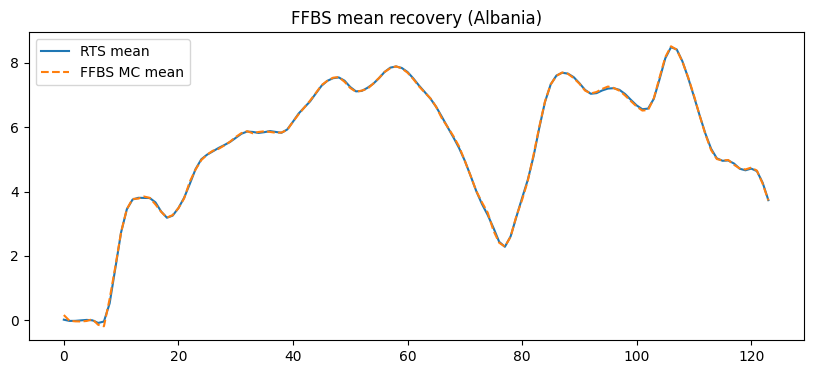

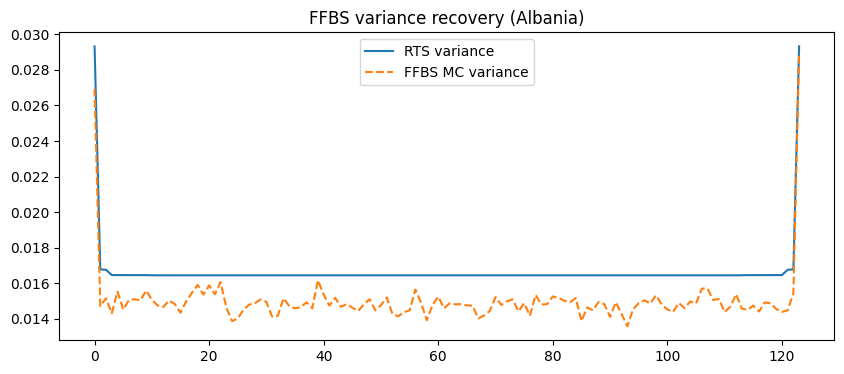

In [38]:
# ============================================================
# FFBS moment recovery sanity check
# ============================================================

model = next(m for m in all_models if m['p'] == 6)

rho_vec = model['rho_vec']
A = make_companion_matrix(rho_vec)

country = countries[0]

res = model['results'][country]

n_draws = 2000

print("=" * 60)
print("FFBS MOMENT RECOVERY")
print("=" * 60)

draws = np.array([
    sample_trajectory_arp(
        res['mu_s_p'],
        res['Sig_s_p'],
        res['mu_p_p'],
        res['Sig_p_p'],
        A
    )
    for _ in range(n_draws)
])

# ------------------------------------------------
# full state recovery
# ------------------------------------------------

mean_mc = draws.mean(axis=0)

var_mc = np.zeros_like(mean_mc)

for j in range(mean_mc.shape[1]):
    var_mc[:, j] = draws[:, :, j].var(axis=0)

mean_rts = res['mu_s_p']

var_rts = np.zeros_like(mean_rts)

for j in range(mean_rts.shape[1]):
    var_rts[:, j] = res['Sig_s_p'][:, j, j]

print(
    "max mean error:",
    np.max(np.abs(mean_mc - mean_rts))
)

print(
    "mean mean error:",
    np.mean(np.abs(mean_mc - mean_rts))
)

print(
    "max variance error:",
    np.max(np.abs(var_mc - var_rts))
)

print(
    "mean variance error:",
    np.mean(np.abs(var_mc - var_rts))
)

# ------------------------------------------------
# latent state S_t only
# ------------------------------------------------

mean_mc_S = draws[:, :, 0].mean(axis=0)
var_mc_S  = draws[:, :, 0].var(axis=0)

mean_rts_S = res['mu_s_p'][:, 0]
var_rts_S  = res['Sig_s_p'][:, 0, 0]

print("\nLatent state S_t only")

print(
    "max S mean error:",
    np.max(np.abs(mean_mc_S - mean_rts_S))
)

print(
    "mean S mean error:",
    np.mean(np.abs(mean_mc_S - mean_rts_S))
)

print(
    "max S variance error:",
    np.max(np.abs(var_mc_S - var_rts_S))
)

print(
    "mean S variance error:",
    np.mean(np.abs(var_mc_S - var_rts_S))
)

# ------------------------------------------------
# visual check
# ------------------------------------------------

plt.figure(figsize=(10,4))

plt.plot(
    mean_rts_S,
    label='RTS mean'
)

plt.plot(
    mean_mc_S,
    '--',
    label='FFBS MC mean'
)

plt.title(f'FFBS mean recovery ({country})')
plt.legend()
plt.show()


plt.figure(figsize=(10,4))

plt.plot(
    var_rts_S,
    label='RTS variance'
)

plt.plot(
    var_mc_S,
    '--',
    label='FFBS MC variance'
)

plt.title(f'FFBS variance recovery ({country})')
plt.legend()
plt.show()

In [39]:
# ============================================================
# Scalar FFBS (M0/M1)
# ============================================================

def sample_trajectory(ES, VS, Cov):

    T = len(ES)

    S = np.zeros(T)

    S[T-1] = np.random.normal(
        ES[T-1],
        np.sqrt(max(VS[T-1], 1e-8))
    )

    for t in range(T-2, -1, -1):

        J = Cov[t+1] / VS[t+1]

        mean = ES[t] + J * (S[t+1] - ES[t+1])

        var = max(
            VS[t] - J * Cov[t+1],
            1e-8
        )

        S[t] = np.random.normal(
            mean,
            np.sqrt(var)
        )

    return S


# ============================================================
# AR(p) FFBS
# ============================================================

def sample_trajectory_arp(
    mu_s_p,
    Sig_s_p,
    mu_p_p,
    Sig_p_p,
    A
):

    T, d = mu_s_p.shape

    X = np.zeros((T, d))

    X[-1] = np.random.multivariate_normal(
        mu_s_p[-1],
        Sig_s_p[-1]
    )

    for t in range(T - 2, -1, -1):

        Sig_p_reg = (
            Sig_p_p[t+1]
            + 1e-10 * np.eye(d)
        )

        G_t = (
            Sig_s_p[t]
            @ A.T
            @ np.linalg.inv(Sig_p_reg)
        )

        mean = (
            mu_s_p[t]
            + G_t @ (
                X[t+1]
                - mu_p_p[t+1]
            )
        )

        cov = (
            Sig_s_p[t]
            - G_t @ Sig_p_p[t+1] @ G_t.T
        )

        cov = (
            (cov + cov.T)/2
            + 1e-10*np.eye(d)
        )

        X[t] = np.random.multivariate_normal(
            mean,
            cov
        )

    return X[:, 0]


# ============================================================
# Unified posterior sampler
# ============================================================

def sample_posterior_for_model(
    m,
    n_samples=300
):

    out = {}

    is_arp = (
        m.get('rho_vec', None) is not None
    )

    if is_arp:

        A = make_companion_matrix(
            m['rho_vec']
        )

    for country in countries:

        res = m['results'][country]

        if is_arp:

            samples = np.array([
                sample_trajectory_arp(
                    res['mu_s_p'],
                    res['Sig_s_p'],
                    res['mu_p_p'],
                    res['Sig_p_p'],
                    A
                )
                for _ in range(n_samples)
            ])

        else:

            ES = res['ES']

            VS = (
                res['ES2']
                - ES**2
            )

            Cov = np.zeros_like(ES)

            Cov[1:] = (
                res['ESS']
                - ES[1:] * ES[:-1]
            )

            samples = np.array([
                sample_trajectory(
                    ES,
                    VS,
                    Cov
                )
                for _ in range(n_samples)
            ])

        out[country] = {
            'S_samples': samples,
            'dates': res['dates']
        }

    return out

In [40]:
N_SAMPLES = 300

model_samples = {}

for m in all_models:

    print(f"Sampling {m['label']} ...")

    model_samples[m['label']] = sample_posterior_for_model(
        m,
        n_samples=N_SAMPLES
    )

Sampling M0 ...


Sampling M1 ...
Sampling AR(1) ...
Sampling AR(2) ...
Sampling AR(3) ...
Sampling AR(4) ...


/tmp/ipykernel_641161/2123164731.py:87: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X[t] = np.random.multivariate_normal(


Sampling AR(5) ...
Sampling AR(6) ...


In [41]:
with open(f'../data/model_samples_arp_{freq}.pkl', 'wb') as f:
    pickle.dump(model_samples, f)
print(f"Saved model_samples_arp_{freq}.pkl")

Saved model_samples_arp_seasonal.pkl


## Diagnostics

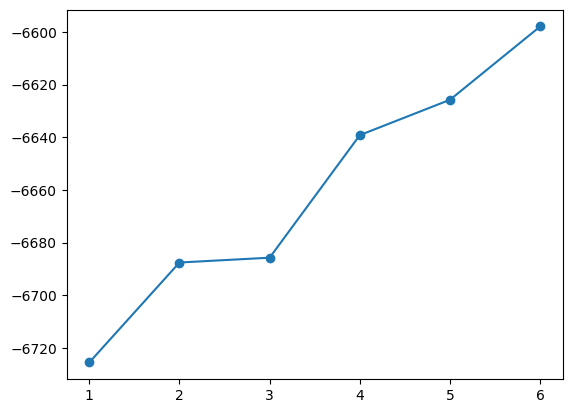

In [42]:
# --------------------------------------------------
# log_ml vs p
# --------------------------------------------------
ps = []
logml = []

for m in all_models:
    if m['rho_vec'] is not None:
        ps.append(len(m['rho_vec']))
        logml.append(m['final_log_ml'])

plt.plot(ps, logml, marker='o')

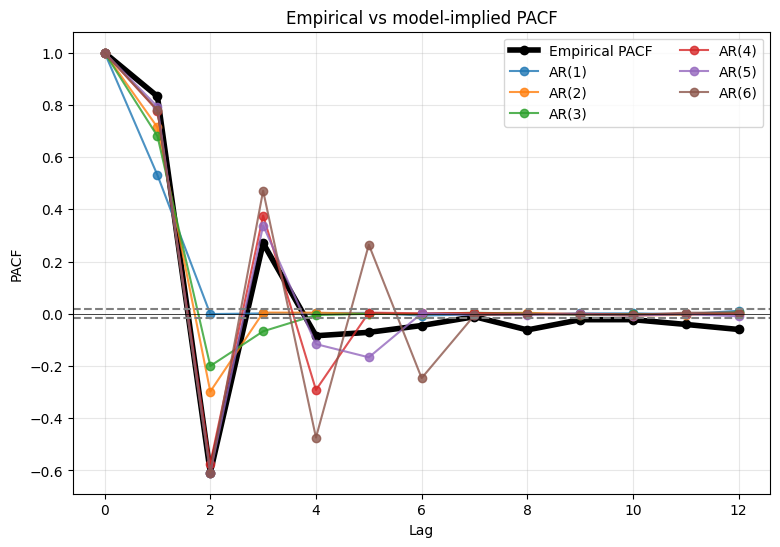

In [43]:
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# empirical PACF of smoothed increments
# --------------------------------------------------

ar2 = next(m for m in all_models if m['p'] == 2)

all_D = []

for country, res in ar2['results'].items():
    all_D.append(np.diff(res['ES']))

D_all = np.concatenate(all_D)

pacf_emp = pacf(D_all, nlags=12, method='ywm')

# --------------------------------------------------
# plot
# --------------------------------------------------

plt.figure(figsize=(9,6))

plt.plot(
    range(len(pacf_emp)),
    pacf_emp,
    marker='o',
    linewidth=4,
    color='black',
    label='Empirical PACF'
)

for p in range(1, 7):

    model = next(m for m in all_models if m['p'] == p)

    rho = np.asarray(model['rho_vec'])

    ar_poly = np.r_[1, -rho]

    arma = ArmaProcess(ar_poly, [1])

    sim = arma.generate_sample(
        nsample=50000,
        burnin=5000
    )

    pacf_model = pacf(
        sim,
        nlags=12,
        method='ywm'
    )

    plt.plot(
        range(len(pacf_model)),
        pacf_model,
        marker='o',
        alpha=0.8,
        label=f'AR({p})'
    )

# approximate significance bounds
bound = 1.96 / np.sqrt(len(D_all))

plt.axhline(bound, linestyle='--', color='gray')
plt.axhline(-bound, linestyle='--', color='gray')
plt.axhline(0, color='black', linewidth=0.5)

plt.xlabel('Lag')
plt.ylabel('PACF')
plt.title('Empirical vs model-implied PACF')
plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.show()

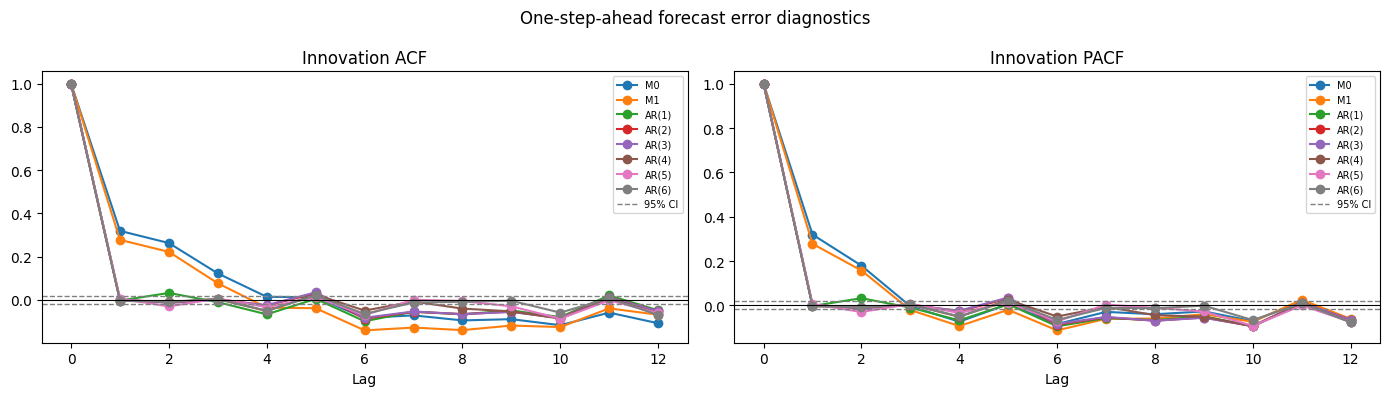

In [44]:
from statsmodels.tsa.stattools import acf, pacf
# ## Diagnostic — one-step-ahead forecast errors (innovations)
#
# $v_t = Y_t - E(Y_t \mid Y_{1:t-1})$
#
# Should be approximately white if the model is well specified.

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model in all_models:

    innov_all = []

    for country, res in model['results'].items():
        # predicted mean before observing Y_t: mu_p for scalar, mu_p_p[:,0] for AR(p)
        if model['rho_vec'] is not None:
            mu_pred = res['mu_p_p'][:, 0]
        else:
            mu_pred = res['mu_p']
        innov_all.append(res['Y'] - mu_pred)

    innov_all = np.concatenate(innov_all)

    # ACF
    acf_vals  = acf(innov_all,  nlags=12, fft=True)
    axes[0].plot(acf_vals,  marker='o', label=model['label'])

    # PACF
    pacf_vals = pacf(innov_all, nlags=12, method='ywm')
    axes[1].plot(pacf_vals, marker='o', label=model['label'])

ci = 1.96 / np.sqrt(sum(
    len(res['Y']) for res in all_models[0]['results'].values()
))

for ax, title in zip(axes, ['Innovation ACF', 'Innovation PACF']):
    ax.axhline( ci, color='gray', linestyle='--', lw=1, label='95% CI')
    ax.axhline(-ci, color='gray', linestyle='--', lw=1)
    ax.axhline(0,   color='black', lw=0.8)
    ax.set_xlabel('Lag')
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.suptitle('One-step-ahead forecast error diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig(f'../data/innovation_acf_pacf_{freq}.png', dpi=150, bbox_inches='tight')
plt.show()

## Holdout evalutaion

In [47]:
def _run_kalman_for_eval(m_tr, country, tau2):
    """Run Kalman filter with train-frozen params for a given country."""

    arp = m_tr['p'] > 0

    # theta_c = m_tr['theta_by_continent'].get(
    #     cont_map[country], 0.0
    # )
    
    theta_c = m_tr['theta'].get(cont_map[country], 0.0)

    mu_seq = compute_mu_t_c(
        country,
        m_tr['beta'],
        theta_c,
        delta=m_tr['delta']
    )

    Y = df_by_country[country]['log_cases'].values.astype(np.float64)

    sigma2 = m_tr['sigma2']

    P0_S = 100.0
    mu_s_1 = 0.0

    if arp:

        A = make_companion_matrix(m_tr['rho_vec'])
        p = m_tr['p']
        d = p + 1

        e = np.zeros(d)
        e[0] = 1.0
        e[1] = 1.0

        Q = sigma2 * np.outer(e, e)

        # same stationary initialization used in training
        A_D = A[1:, 1:]
        Q_D = Q[1:, 1:]

        try:
            P_D = solve_discrete_lyapunov(A_D, Q_D)
        except Exception:
            P_D = sigma2 * np.eye(p)

        P_inf = np.zeros((d, d))
        P_inf[0, 0] = P0_S
        P_inf[1:, 1:] = P_D

        _, Sig_f_p, mu_p_p, Sig_p_p, _ = kalman_filter_arp(
            Y,
            0.0,
            mu_seq,
            tau2,
            mu_s_1,
            P_inf,
            A,
            Q,
            sigma2
        )

        return Y, mu_p_p[:, 0], Sig_p_p[:, 0, 0] + tau2

    else:

        _, Sigma_f, mu_p, Sigma_p, _ = kalman_filter_scalar(
            Y,
            0.0,
            mu_seq,
            tau2,
            mu_s_1,
            P0_S,
            sigma2
        )

        return Y, mu_p, Sigma_p + tau2

TEMPORAL HOLDOUT  (train 80% / test 20%)

Re-fitting 8 models on training time steps …
Done.

Temporal holdout results (97 train countries, last 20% of time):
Model  p   RMSE  PI width  Coverage (95%)
   M0  0 0.6342    1.7792          0.9089
   M1  0 0.6110    1.7181          0.9196
AR(1)  1 0.5967    1.6239          0.9291
AR(2)  2 0.5959    1.6241          0.9295
AR(3)  3 0.5889    1.6194          0.9328
AR(4)  4 0.5881    1.6174          0.9332
AR(5)  5 0.5882    1.6174          0.9332
AR(6)  6 0.5801    1.6080          0.9315


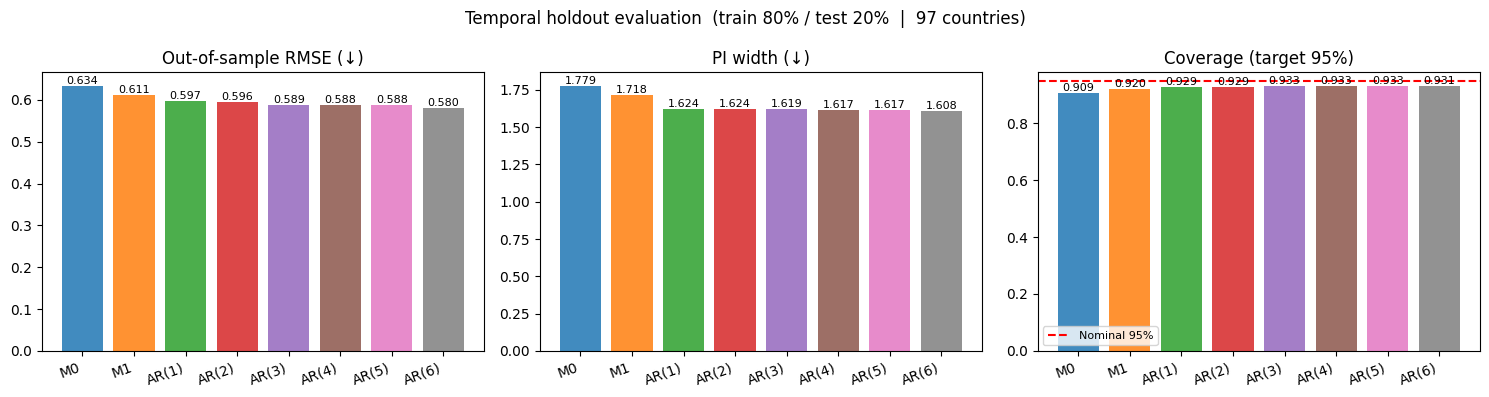

Saved ../data/temporal_holdout_eval_seasonal.png

COUNTRY HOLDOUT  (24 countries withheld from EM)
Holdout set: ['Afghanistan', 'Austria', 'Belarus', 'Belgium', 'Burundi', 'Croatia', 'Dominica', 'Estonia', 'Finland', 'Germany', 'Ghana', 'Guatemala', 'Iran', 'Jordan', 'Kuwait', 'Laos', 'Luxembourg', 'Malta', 'Panama', 'Paraguay', 'South Korea', 'Sweden', 'Togo', 'Uruguay']

Country holdout results (24 countries, full time series):
Model  p   RMSE  PI width  Coverage (95%)
   M0  0 0.4577    2.0810          0.9483
   M1  0 0.4379    2.0204          0.9516
AR(1)  1 0.4144    1.9278          0.9519
AR(2)  2 0.4153    1.9281          0.9516
AR(3)  3 0.4147    1.9236          0.9509
AR(4)  4 0.4145    1.9216          0.9513
AR(5)  5 0.4145    1.9216          0.9516
AR(6)  6 0.4139    1.9127          0.9516


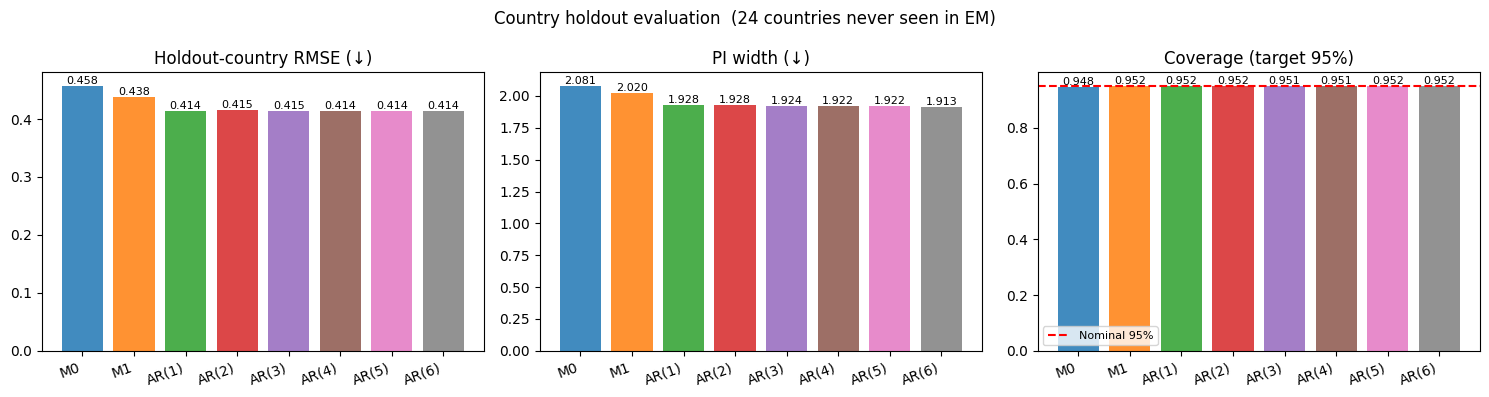

Saved ../data/country_holdout_eval_seasonal.png


COMBINED SUMMARY
Model  RMSE (temporal)  PI width (temporal)  Cov (temporal)  RMSE (country)  PI width (country)  Cov (country)
   M0           0.6342               1.7792          0.9089          0.4577              2.0810         0.9483
   M1           0.6110               1.7181          0.9196          0.4379              2.0204         0.9516
AR(1)           0.5967               1.6239          0.9291          0.4144              1.9278         0.9519
AR(2)           0.5959               1.6241          0.9295          0.4153              1.9281         0.9516
AR(3)           0.5889               1.6194          0.9328          0.4147              1.9236         0.9509
AR(4)           0.5881               1.6174          0.9332          0.4145              1.9216         0.9513
AR(5)           0.5882               1.6174          0.9332          0.4145              1.9216         0.9516
AR(6)           0.5801               1.6080  

In [48]:
# ── Heldout forecasting & country evaluation ──────────────────────────────────
#
# Two evaluations are run here:
#
#   1. Temporal holdout  — last `test_frac` of each country's time series is
#      withheld.  Models are re-fitted on training time steps only; evaluation
#      uses the genuine predictive density p(Y_t | Y_{1:t-1}) for each test
#      observation.
#
#   2. Country holdout   — the 20 % of countries set aside before EM training
#      (`holdout_countries`) are never used during fitting.  Predictions for 
#       holdout countries use the same diffuse state initialization as training 
#       (mean 0, variance P0_S).
#
# Both evaluations report RMSE, predictive-interval width, and empirical
# coverage for every model (M1, AR(1) … AR(6)).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── shared settings ────────────────────────────────────────────────────────────
TEST_FRAC = 0.20
COVERAGE  = 0.95
Z_SCORE   = stats.norm.ppf((1 + COVERAGE) / 2)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

eval_models = all_models

# ══════════════════════════════════════════════════════════════════════════════
# 1. TEMPORAL HOLDOUT — re-fit on train time steps, evaluate on test time steps
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print(f"TEMPORAL HOLDOUT  (train {100*(1-TEST_FRAC):.0f}% / test {100*TEST_FRAC:.0f}%)")
print("=" * 70)

# -- 1a. Re-fit each model using only the first (1-TEST_FRAC) time steps ------
def _refit_on_train_time(base_model):
    train_records = []
    for country in countries:
        df_c  = df_by_country[country]
        t_cut = int(len(df_c) * (1 - TEST_FRAC))
        train_records.append(df_c.iloc[:t_cut])
    df_train = pd.concat(train_records, ignore_index=True)
    return run_EM(
        df          = df_train,
        label       = base_model['label'] + ' [train-time]',
        n_iter      = 500,
        lam         = 1.0,
        lam_delta   = 5.0,
        tol         = 1e-4,
        rho_vec_init = (np.zeros(base_model['p']) if base_model['p'] > 0 else None),
        use_delta   = (base_model['delta'] is not None),
        verbose     = False,
    )

print(f"\nRe-fitting {len(eval_models)} models on training time steps …")
train_time_models = [_refit_on_train_time(m) for m in eval_models]
print(f"Done.\n")

# -- 1b. Evaluate on held-out time steps --------------------------------------
temporal_rows = []

for m_tr, m_full in zip(train_time_models, eval_models):
    label = m_full['label']

    rmse_num = 0.0; width_sum = 0.0; cov_sum = 0.0; n_total = 0

    for country in countries:
        df_c  = df_by_country[country]
        t_cut = int(len(df_c) * (1 - TEST_FRAC))

        Y, pred_mean, pred_var = _run_kalman_for_eval(m_tr, country, m_tr['tau2'])
        pred_std = np.sqrt(pred_var)

        Y_test   = Y[t_cut:]
        mu_test  = pred_mean[t_cut:]
        std_test = pred_std[t_cut:]
        lower    = mu_test - Z_SCORE * std_test
        upper    = mu_test + Z_SCORE * std_test
        n        = len(Y_test)

        rmse_num  += np.sum((Y_test - mu_test) ** 2)
        width_sum += np.sum(upper - lower)
        cov_sum   += np.sum((Y_test >= lower) & (Y_test <= upper))
        n_total   += n

    temporal_rows.append({
        'Model'                       : label,
        'p'                           : m_full['p'],
        'RMSE'                        : round(float(np.sqrt(rmse_num / n_total)), 4),
        'PI width'                    : round(float(width_sum / n_total), 4),
        f'Coverage ({COVERAGE:.0%})' : round(float(cov_sum / n_total), 4),
    })

df_temporal = pd.DataFrame(temporal_rows)
print(f"Temporal holdout results ({len(countries)} train countries, last {100*TEST_FRAC:.0f}% of time):")
print(df_temporal.to_string(index=False))

# -- 1c. Plot temporal holdout -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x         = np.arange(len(df_temporal))
col_list  = [colors[i % len(colors)] for i in range(len(df_temporal))]

cov_col = f'Coverage ({COVERAGE:.0%})'
for ax, col_name, title, hline in [
    (axes[0], 'RMSE',      'Out-of-sample RMSE (↓)',                None),
    (axes[1], 'PI width',  'PI width (↓)',                          None),
    (axes[2], cov_col,     f'Coverage (target {COVERAGE:.0%})',     COVERAGE),
]:
    bars = ax.bar(x, df_temporal[col_name], color=col_list, alpha=0.85)
    if hline is not None:
        ax.axhline(hline, color='red', ls='--', lw=1.5,
                   label=f'Nominal {COVERAGE:.0%}')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_temporal['Model'], rotation=20, ha='right')
    ax.set_title(title)
    for bar, v in zip(bars, df_temporal[col_name]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Temporal holdout evaluation  '
    f'(train {100*(1-TEST_FRAC):.0f}% / test {100*TEST_FRAC:.0f}%  |  '
    f'{len(countries)} countries)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'../data/temporal_holdout_eval_{freq}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved ../data/temporal_holdout_eval_{freq}.png\n")

# ══════════════════════════════════════════════════════════════════════════════
# 2. COUNTRY HOLDOUT — countries never seen during EM training
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print(f"COUNTRY HOLDOUT  ({len(holdout_countries)} countries withheld from EM)")
print("=" * 70)
print(f"Holdout set: {sorted(holdout_countries)}\n")

# Use the train-time models from step 1 (fitted on train countries & train time).
# No country-specific initialization is used. All countries start from the common diffuse prior.
country_rows = []

for m_tr, m_full in zip(train_time_models, eval_models):
    label = m_full['label']

    rmse_num = 0.0; width_sum = 0.0; cov_sum = 0.0; n_total = 0

    for country in holdout_countries:
        # Pass an empty mu0_c so _run_kalman_for_eval uses mu0_prior as fallback
        Y, pred_mean, pred_var = _run_kalman_for_eval(m_tr, country, m_tr['tau2'])
        pred_std = np.sqrt(pred_var)
        lower    = pred_mean - Z_SCORE * pred_std
        upper    = pred_mean + Z_SCORE * pred_std
        n        = len(Y)

        rmse_num  += np.sum((Y - pred_mean) ** 2)
        width_sum += np.sum(upper - lower)
        cov_sum   += np.sum((Y >= lower) & (Y <= upper))
        n_total   += n

    country_rows.append({
        'Model'                       : label,
        'p'                           : m_full['p'],
        'RMSE'                        : round(float(np.sqrt(rmse_num / n_total)), 4),
        'PI width'                    : round(float(width_sum / n_total), 4),
        f'Coverage ({COVERAGE:.0%})' : round(float(cov_sum / n_total), 4),
    })

df_country = pd.DataFrame(country_rows)
print(f"Country holdout results ({len(holdout_countries)} countries, full time series):")
print(df_country.to_string(index=False))

# -- 2b. Plot country holdout --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x        = np.arange(len(df_country))
col_list = [colors[i % len(colors)] for i in range(len(df_country))]

for ax, col_name, title, hline in [
    (axes[0], 'RMSE',     'Holdout-country RMSE (↓)',               None),
    (axes[1], 'PI width', 'PI width (↓)',                            None),
    (axes[2], cov_col,    f'Coverage (target {COVERAGE:.0%})',       COVERAGE),
]:
    bars = ax.bar(x, df_country[col_name], color=col_list, alpha=0.85)
    if hline is not None:
        ax.axhline(hline, color='red', ls='--', lw=1.5,
                   label=f'Nominal {COVERAGE:.0%}')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_country['Model'], rotation=20, ha='right')
    ax.set_title(title)
    for bar, v in zip(bars, df_country[col_name]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    f'Country holdout evaluation  '
    f'({len(holdout_countries)} countries never seen in EM)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'../data/country_holdout_eval_{freq}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved ../data/country_holdout_eval_{freq}.png\n")

# ══════════════════════════════════════════════════════════════════════════════
# 3. COMBINED SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

df_temporal_tag = df_temporal.rename(columns={
    'RMSE':    'RMSE (temporal)',
    'PI width': 'PI width (temporal)',
    cov_col:   f'Cov (temporal)',
})
df_country_tag = df_country.rename(columns={
    'RMSE':    'RMSE (country)',
    'PI width': 'PI width (country)',
    cov_col:   f'Cov (country)',
})

df_summary = df_temporal_tag.merge(
    df_country_tag[['Model', 'RMSE (country)', 'PI width (country)', 'Cov (country)']],
    on='Model',
)

print("\n" + "=" * 70)
print("COMBINED SUMMARY")
print("=" * 70)
print(df_summary.drop(columns='p').to_string(index=False))

## Save

In [53]:
with open(f'../data/all_models_arp_{freq}.pkl','wb') as f:
    pickle.dump(all_models,f)
print(f"Saved all_models_arp_{freq}.pkl  ({len(all_models)} models)")

for m in all_models:
    tag=m['label'].split('—')[0].strip().lower().replace(' ','_')
    records=[]
    for country in countries:
        ES=m['results'][country]['ES']; dates=m['results'][country]['dates']
        for t in range(1,len(ES)):
            records.append({'country':country,'date':dates[t],
                            'R_plug_in':np.exp(ES[t]-ES[t-1]),'model':m['label']})
    pd.DataFrame(records).to_csv(f'../data/R_plugin_arp_{freq}_{tag}.csv',index=False)
print("Saved R plug-in CSVs")

Saved all_models_arp_seasonal.pkl  (8 models)
Saved R plug-in CSVs
